In [24]:
import os
import pandas as pd
import geopandas as gpd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize
from matplotlib.lines import lineStyles
from matplotlib.pyplot import ylabel


In [25]:

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update(
    {
        # figure
        # 'figure.facecolor': 'white',
        'figure.edgecolor': 'white',
        'figure.figsize': (10, 6),
        'figure.dpi': 100,

        # axes
        'axes.facecolor': 'white',
        'axes.edgecolor': 'black',
        'axes.linewidth': 0.8,
        'axes.grid': True,
        'axes.titlesize': 14,
        'axes.titleweight': 'normal',
        'axes.labelsize': 11,
        'axes.labelweight': 'normal',
        'axes.spines.top': False,
        'axes.spines.right': False,
        # grid
        'grid.color': 'gray',
        'grid.alpha': 0.3,
        'grid.linestyle': ':',
        'grid.linewidth': 0.5,
        # ticks

        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'xtick.color': 'black',
        'ytick.color': 'black',
        'xtick.direction': 'out',
        'ytick.direction': 'out',

        # lines
        'lines.linewidth': 2,
        'lines.markersize': 6,
        # font

        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans'],
        'font.size': 10,

        # legend

        'legend.frameon': False,
        'legend.fontsize': 10
    }
)


COLORS = {
    # Primary categories
    'proposed':   '#E07B54',   # warm orange  — proposed data centers
    'operating':  '#4F8EF7',   # blue         — operating data centers
    'superfund':  '#6ABF69',   # green        — superfund sites

    # Pre/Post EO
    'pre_eo':     '#A8BFDB',   # muted blue
    'post_eo':    '#E8A838',   # amber

    # Regions
    'northeast':  '#7B6FAB',   # purple
    'south':      '#E07B54',   # warm orange
    'midwest':    '#4F8EF7',   # blue
    'west':       '#6ABF69',   # green

    # Neutral / supporting
    'highlight':  '#E84B4B',   # red          — callout/alert
    'neutral':    '#AAAAAA',   # gray         — background/reference
    'background': '#F7F7F7',   # off-white
}


STATUS_PALETTE   = {
    'Proposed':  COLORS['proposed'],
    'Operating': COLORS['operating'],
}

REGION_PALETTE   = {
    'Northeast': COLORS['northeast'],
    'South':     COLORS['south'],
    'Midwest':   COLORS['midwest'],
    'West':      COLORS['west'],
}

EO_PALETTE       = {
    False: COLORS['pre_eo'],
    True:  COLORS['post_eo'],
}



In [26]:
DATA_CENTERS_DIR = "../data/raw/data_centers"
SUPERFUND_DIR = "../data/raw/epa_superfund"
DATA_CENTERS_FILE = "data_centers_raw.csv"
SUPERFUND_FILE = "superfund_raw.csv"
dc_df = pd.read_csv(os.path.join(DATA_CENTERS_DIR, DATA_CENTERS_FILE))
dc_gdf = gpd.read_file(os.path.join(DATA_CENTERS_DIR, DATA_CENTERS_FILE))
sf_df = pd.read_csv(os.path.join(SUPERFUND_DIR, SUPERFUND_FILE))
sf_gdf = gpd.read_file(os.path.join(SUPERFUND_DIR, SUPERFUND_FILE))

In [58]:
sf_gdf['GIS_AREA'] = pd.to_numeric(sf_gdf['GIS_AREA'], errors='coerce')


In [27]:
print(dc_gdf.head())

                              facility_name                       address  \
0                            Project Marvel         Rock Mountain Lake Rd   
1                                   DC Blox                  433 6th St S   
2                        Google Data Center             48809 Alabama 277   
3  Western Hospitality Partners Data Center  Childersburg Industrial Park   
4                                   DC Blox             333 Diamond Dr NW   

           city state      zip     county        lat        long     status  \
0      Bessemer    AL  35022.0  Jefferson     33.342    -87.0341   Proposed   
1    Birmingham    AL  35233.0  Jefferson   33.50051     -86.821  Operating   
2    Bridgeport    AL  35740.0    Jackson   34.92019    -85.7446  Operating   
3  Childersburg    AL  35044.0  Talladega  33.340885  -86.336205   Proposed   
4    Huntsville    AL  35806.0    Madison   34.71003     -86.693  Operating   

  location_confidence  ...                                    

In [28]:
print(sf_gdf.head())

  OBJECTID REGION_CODE         EPA_PROGRAM        EPA_ID  \
0        1           1  Superfund Remedial  CTD001452093   
1        2           1  Superfund Remedial  VTD000860239   
2        3           1  Superfund Remedial  VTD981062441   
3        4           1  Superfund Remedial  VTD980523062   
4        5           1  Superfund Remedial  NHD980671069   

                           SITE_NAME SITE_FEATURE_CLASS  \
0                     DURHAM MEADOWS                  5   
1           OLD SPRINGFIELD LANDFILL                  5   
2           PARKER SANITARY LANDFILL                  5   
3                  PINE STREET CANAL                  5   
4  SOUTH MUNICIPAL WATER SUPPLY WELL                  5   

         SITE_FEATURE_TYPE                                  SITE_FEATURE_NAME  \
0  Extent of Contamination           Approximate Durham Meadows Site Boundary   
1  OU Boundary Aggregation  Approximate Old Springfield Landfill Site Boun...   
2  Comprehensive Site Area  Approximate P

In [29]:
# - spatial proximity analysis
# - proposed vs operating comparisus
# -

In [30]:
print(dc_df.shape)
print(dc_df.dtypes)

(1473, 44)
facility_name                 object
address                       object
city                          object
state                         object
zip                          float64
county                        object
lat                          float64
long                         float64
status                        object
location_confidence           object
purpose                       object
operator_name                 object
tenant                        object
mw                            object
sizerank                      object
power_source                  object
dedicated_power_plant         object
number_of_generators          object
number_of_buildings           object
cooling_source                object
cooling_type                  object
facility_size_sqft            object
property_size_acres          float64
project_cost                  object
expected_date_online          object
community_pushback            object
advocacy_information       

In [31]:
missing_dc = dc_df.isnull().sum()
missing_dc_pct = (missing_dc / len(dc_df) * 100).round(1)
missing_dc_df = pd.DataFrame({'missing_n': missing_dc, 'missing_pct': missing_dc_pct})
missing_dc_df.sort_values('missing_pct', ascending=False)

,missing_n,missing_pct
nda,1469,99.7
number_of_generators,1462,99.3
info_source_8,1461,99.2
community_group_website_2,1452,98.6
tenant,1449,98.4
dedicated_power_plant,1449,98.4
info_source_7,1450,98.4
resistance_status,1442,97.9
info_source_6,1436,97.5
cooling_source,1436,97.5


In [32]:
source_cols = [c for c in dc_df.columns if c.startswith('info_sourse_')]
dc_df['source_count'] = dc_df[source_cols].apply(lambda r: r.astype(str).str.strip().ne('').sum(), axis=1)
dc_df['source_count'].value_counts().sort_index()

source_count
0    1473
Name: count, dtype: int64

In [33]:
dc_df['status'].value_counts()

status
Proposed                                 670
Operating                                529
Approved/Permitted/Under construction    131
Expanding                                 52
Cancelled                                 45
Suspended                                 45
Unknown                                    1
Name: count, dtype: int64

In [34]:
dc_df['status'].value_counts(normalize=True).mul(100).round(1)

status
Proposed                                 45.5
Operating                                35.9
Approved/Permitted/Under construction     8.9
Expanding                                 3.5
Cancelled                                 3.1
Suspended                                 3.1
Unknown                                   0.1
Name: proportion, dtype: float64

In [35]:
dc_df['date_created'] = pd.to_datetime(dc_df['date_created'], format='%m/%d/%Y', errors="coerce")
dc_df['date_updated'] = pd.to_datetime(dc_df['date_updated'], format='%m/%d/%Y', errors="coerce")

In [36]:
print(f"\ndate_created range: {dc_df['date_created'].min()} -> {dc_df['date_created'].max()}")
print(f"data updated range: {dc_df['date_updated'].min()} {dc_df['date_updated'].max() }")
print(f"unparseable dates: {dc_df['date_created'].isnull().sum()}")


date_created range: 2024-04-10 00:00:00 -> 2026-04-23 00:00:00
data updated range: 2025-01-04 00:00:00 2026-04-27 00:00:00
unparseable dates: 4


In [37]:
EO_DATE = pd.Timestamp('2025-07-01')
dc_df['post_eo'] = dc_df['date_created'] >= EO_DATE

print(f"Pre EO entries: {(~dc_df['post_eo']).sum()  }")
print(f"Post EO entries: {dc_df['post_eo'].sum()  }")

print(f"\n Status x EO period: \n {pd.crosstab(dc_df['status'], dc_df['post_eo'], margins=True)}")

Pre EO entries: 468
Post EO entries: 1005

 Status x EO period: 
 post_eo                                False  True   All
status                                                  
Approved/Permitted/Under construction     29   102   131
Cancelled                                  8    37    45
Expanding                                 20    32    52
Operating                                206   323   529
Proposed                                 200   470   670
Suspended                                  5    40    45
Unknown                                    0     1     1
All                                      468  1005  1473


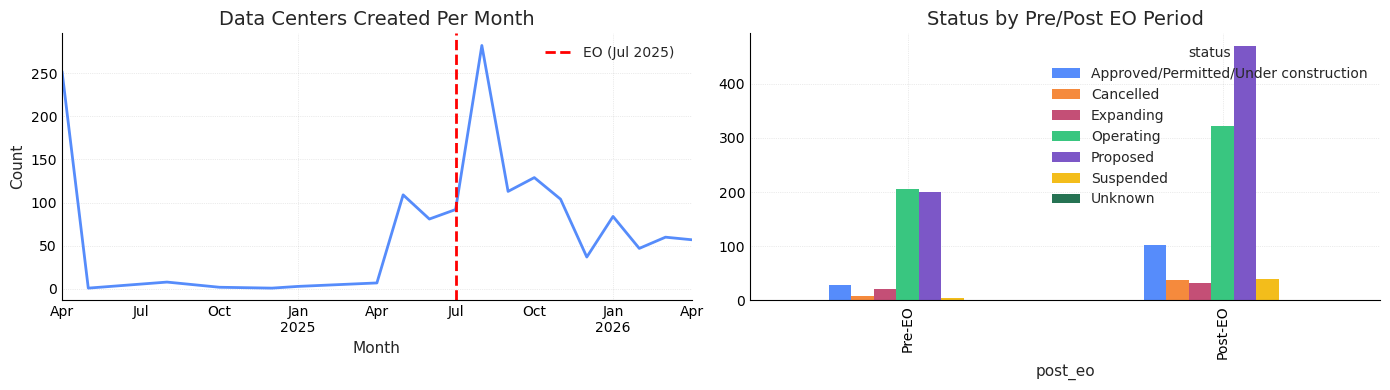

In [39]:
# plot DC creation over time
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dc_df.groupby(
    dc_df['date_created'].dt.to_period('M')).size().plot(
    ax=axes[0], title="Data Centers Created Per Month", xlabel="Month", ylabel="Count"
)
axes[0].axvline(pd.Period('2025-07', 'M'), color='red', linestyle='--', label='EO (Jul 2025) ')
axes[0].legend()

dc_df.groupby(['post_eo', 'status']).size().unstack().plot(
    kind='bar', ax=axes[1], title="Status by Pre/Post EO Period"
)
axes[1].set_xticklabels(['Pre-EO', 'Post-EO'])
plt.tight_layout()
plt.show()

In [40]:
print(f" Top 15 states: {dc_df['state'].value_counts().head(15)}")
print(f"Total states represented: {dc_df['state'].nunique()}")

 Top 15 states: state
VA    452
TX    177
GA    174
PA     98
OH     53
IN     37
NY     34
IL     31
AZ     29
NC     28
CA     25
MO     24
MI     23
OR     19
IA     19
Name: count, dtype: int64
Total states represented: 47


In [41]:
region_map = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast',
    'RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
    'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest',
    'ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South',
    'VA':'South','DC':'South','WV':'South','AL':'South','KY':'South','MS':'South',
    'TN':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West',
    'UT':'West','WY':'West','AK':'West','CA':'West','HI':'West','OR':'West','WA':'West'
}
dc_df['census_region'] = dc_df['state'].map(region_map)


In [42]:
print(f"by census region: {dc_df['census_region'].value_counts()}")
print(f"Status x Region: \n {pd.crosstab(dc_df['census_region'], dc_df['status'], margins=True)}")

by census region: census_region
South        937
Midwest      237
Northeast    155
West         144
Name: count, dtype: int64
Status x Region: 
 status         Approved/Permitted/Under construction  Cancelled  Expanding  \
census_region                                                                
Midwest                                           33         17          2   
Northeast                                          4          8          3   
South                                             74         17         42   
West                                              20          3          5   
All                                              131         45         52   

status         Operating  Proposed  Suspended  Unknown   All  
census_region                                                 
Midwest               48       117         20        0   237  
Northeast             66        68          5        1   155  
South                358       428         18        0  

In [43]:
missing_coords = dc_df[['lat', 'long']].isnull().any(axis=1).sum()
print(f"Rows missing lat/long: {missing_coords}")
print(f"location_confidence breakdown:\n {dc_df['location_confidence'].value_counts()}")

Rows missing lat/long: 0
location_confidence breakdown:
 location_confidence
High       1175
Medium      246
Low          46
Medium        3
High          2
high          1
Name: count, dtype: int64


In [44]:
# section 4
print(f"Shape: {sf_gdf.shape}")
print(f"Dtypes: {sf_gdf.dtypes}")

Shape: (2114, 33)
Dtypes: OBJECTID                         object
REGION_CODE                      object
EPA_PROGRAM                      object
EPA_ID                           object
SITE_NAME                        object
SITE_FEATURE_CLASS               object
SITE_FEATURE_TYPE                object
SITE_FEATURE_NAME                object
SITE_FEATURE_DESCRIPTION         object
NPL_STATUS_CODE                  object
FEDERAL_FACILITY_DETER_CODE      object
LAST_CHANGE_DATE                 object
ORIGINAL_CREATION_DATE           object
SITE_FEATURE_SOURCE              object
STREET_ADDR_TXT                  object
ADDR_COMMENT                     object
CITY_NAME                        object
COUNTY                           object
STATE_CODE                       object
ZIP_CODE                         object
SITE_CONTACT_NAME                object
PRIMARY_TELEPHONE_NUM            object
SITE_CONTACT_EMAIL               object
URL_ALIAS_TXT                    object
FEATURE_INFO_U

In [45]:
missing_sf = sf_gdf.isnull().sum()
missing_sf_pct = (missing_sf / len(sf_gdf) * 100).round(1)
missing_sf_df = pd.DataFrame({
    'missing_n': missing_sf,
    'missing_pct': missing_sf_pct
})
print(f"Missingness: {missing_sf_df[missing_sf_df.missing_n > 0].sort_values('missing_pct', ascending=False)}")


Missingness: Empty DataFrame
Columns: [missing_n, missing_pct]
Index: []


In [61]:
# section 5
print(f"NLP_STATUS_CODE breakdown: {sf_gdf['NPL_STATUS_CODE'].value_counts()  }")
print(f"SITE_FEATURE_TYPE breakdown: {sf_gdf['SITE_FEATURE_TYPE'].value_counts()  }")
print(f"EPA REGION_CODE breakdown: {sf_gdf['REGION_CODE'].value_counts().sort_index()  }")

print(f"Total rows: {len(sf_gdf)}")
print(f"Unique EPA_IDs (sites): {sf_gdf['EPA_ID'].nunique()}")
print(f"Avg feature rows per site: {len(sf_gdf) / sf_gdf['EPA_ID'].nunique():.1f}")
print(f"GIS_AREA stats (acres): {sf_gdf['GIS_AREA'].describe().round(2)}")

print(f"\nGIS_AREA (acres) — non-null count: {sf_gdf['GIS_AREA'].notnull().sum()} of {len(sf_gdf)}")
print(f"\nGIS_AREA stats (acres):\n{sf_gdf['GIS_AREA'].describe().round(2)}")
print(f"\nValues that failed to parse (coerced to NaN): {sf_gdf['GIS_AREA'].isnull().sum()}")



NLP_STATUS_CODE breakdown: NPL_STATUS_CODE
F    1530
D     462
N      70
P      36
R      10
A       4
S       2
Name: count, dtype: int64
SITE_FEATURE_TYPE breakdown: SITE_FEATURE_TYPE
Comprehensive Site Area                       886
Current Ground Boundary                       554
Total Site Polygon/OU Aggregation             187
Site Boundary                                 172
Extent of Contamination                       155
OU Boundary Aggregation                        68
Other                                          53
<Null>                                         17
Contamination Boundary                          7
                                                6
Contamination Boundary (Groundwater)            5
Waste in Place                                  1
Comprehensive Site Boundary                     1
OU Boundary                                     1
Total Site Polygon/OU Boundary Aggregation      1
Name: count, dtype: int64
EPA REGION_CODE breakdown: REGION_CODE

In [53]:
proposed = dc_df[dc_df['status'] == 'Proposed']
operating = dc_df[dc_df['status'] == 'Operating']
print(f"Proposed DC: {len(proposed)}")
print(f" - Post-EO: {proposed['post_eo'].sum()}")
print(f" - Pre-EO: {(~proposed['post_eo']).sum()}")

print(f"Operating DCs: {len(operating)}")
print(f" - Post-EO: {operating['post_eo'].sum()}")
print(f" - Pre-EO: {(~operating['post_eo']).sum()}")

print(f"DCs with valid coordinates: {dc_df[['lat', 'long']].notnull().all(axis=1).sum()}")
print(f"SF sites with geometry: {sf_gdf['geometry_wkt'].notnull().sum()}")
print(f"")

Proposed DC: 670
 - Post-EO: 470
 - Pre-EO: 200
Operating DCs: 529
 - Post-EO: 323
 - Pre-EO: 206
DCs with valid coordinates: 1473
SF sites with geometry: 2114



In [62]:
# Normalize by time window to get rate of proposals
pre_eo_days  = (EO_DATE - dc_df['date_created'].min()).days
post_eo_days = (dc_df['date_created'].max() - EO_DATE).days

pre_proposed  = (~dc_df['post_eo'] & (dc_df['status'] == 'Proposed')).sum()
post_proposed = (dc_df['post_eo']  & (dc_df['status'] == 'Proposed')).sum()

print(f"Pre-EO  proposal rate:  {pre_proposed  / pre_eo_days:.2f} per day")
print(f"Post-EO proposal rate:  {post_proposed / post_eo_days:.2f} per day")
print(f"Rate multiplier: {(post_proposed / post_eo_days) / (pre_proposed / pre_eo_days):.1f}x")

Pre-EO  proposal rate:  0.45 per day
Post-EO proposal rate:  1.59 per day
Rate multiplier: 3.5x



# what does it mean to be "near" the superfund sight?

In [ ]:
# what does it mean to be "near" the superfund sight?

# 0.5 miles - direct adjacency, on-site
# 1 mile = EPA's own standard for exposure assessments (let's use this)
# 3 miles - broader community impact zone
# 5 miles - regional influence
# start with 1 mile

# SF features - EPA_ID, COMPREHENSIVE_SITE_AREA

# APPROACH ONE
# DC centric: for each data center, find the distance to its nearest SF site -> binary flag + continuous distance variable
# SF centric: for each SF site, how many DCs fall within X miles - for regional clustering

# outputs:
- distance to nearest sf
- near sf Xmi
- nearest SF name
- nearest_sf_npl_status
- dc_count_within_Xmi per SF site

